In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/muhammadmunsoorulhaq/cv-project/PKG - BraTS-PEDs-v1/BraTS-PEDs-v1/Validation/BraTS-PED-00281-000/BraTS-PED-00281-000-t1c.nii/T1CE_to_SRI_defaced.nii
/kaggle/input/datasets/muhammadmunsoorulhaq/cv-project/PKG - BraTS-PEDs-v1/BraTS-PEDs-v1/Validation/BraTS-PED-00281-000/BraTS-PED-00281-000-t2f.nii/FL_to_SRI_defaced.nii
/kaggle/input/datasets/muhammadmunsoorulhaq/cv-project/PKG - BraTS-PEDs-v1/BraTS-PEDs-v1/Validation/BraTS-PED-00281-000/BraTS-PED-00281-000-t2w.nii/T2_to_SRI_defaced.nii
/kaggle/input/datasets/muhammadmunsoorulhaq/cv-project/PKG - BraTS-PEDs-v1/BraTS-PEDs-v1/Validation/BraTS-PED-00281-000/BraTS-PED-00281-000-t1n.nii/T1_to_SRI_defaced.nii
/kaggle/input/datasets/muhammadmunsoorulhaq/cv-project/PKG - BraTS-PEDs-v1/BraTS-PEDs-v1/Validation/BraTS-PED-00326-000/BraTS-PED-00326-000-t1n.nii/T1_to_SRI_defaced.nii
/kaggle/input/datasets/muhammadmunsoorulhaq/cv-project/PKG - BraTS-PEDs-v1/BraTS-PEDs-v1/Validation/BraTS-PED-00326-000/BraTS-PED-00326-000-t2w.nii/

# Final Project: Deep Vision Pipeline — 3D Swin-UNETR 
Dataset: BraTS-PEDs (pediatric brain tumor MRI, NIfTI format)

Architecture: 3D Swin-UNETR (Vision Transformer)
Input:  3-channel 3D patches [T1CE, T2, FLAIR]  →  (B, 3, 64, 64, 64)
Output: Per-voxel segmentation logits           →  (B, 5, 64, 64, 64)
Loss:   DiceCELoss (MONAI native)
Eval:   Sliding Window Inference + Dice Score

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-05-14 11:46:00.295408: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778759160.487336     807 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778759160.543010     807 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778759160.999832     807 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778759160.999870     807 computation_placer.cc:1

Scanning /kaggle/input/datasets/muhammadmunsoorulhaq/cv-project/PKG - BraTS-PEDs-v1/BraTS-PEDs-v1/Training ... Found 257 patient folders.
--> Successfully loaded 255 fully-labeled patients.

[DATA SPLIT] Automatically splitting labeled data:
  --> 204 patients for Training
  --> 51 patients for Validation

[1/3] Training 3D UNETR...

[RAM SAVER] Initializing lazy-loading Datasets (reads from disk on the fly)...
Ep 001/50 | Loss: 2.1595 | Val Mean Dice: 0.0541
Ep 002/50 | Loss: 1.8569 | Val Mean Dice: 0.0813
Ep 003/50 | Loss: 1.7408 | Val Mean Dice: 0.1043
Ep 004/50 | Loss: 1.6549 | Val Mean Dice: 0.2670
Ep 005/50 | Loss: 1.5861 | Val Mean Dice: 0.2267
Ep 006/50 | Loss: 1.5292 | Val Mean Dice: 0.2453
Ep 007/50 | Loss: 1.4702 | Val Mean Dice: 0.2772
Ep 008/50 | Loss: 1.4270 | Val Mean Dice: 0.2771
Ep 009/50 | Loss: 1.3965 | Val Mean Dice: 0.2998
Ep 010/50 | Loss: 1.3552 | Val Mean Dice: 0.2557
Ep 011/50 | Loss: 1.3330 | Val Mean Dice: 0.2718
Ep 012/50 | Loss: 1.3126 | Val Mean Dice: 0.32

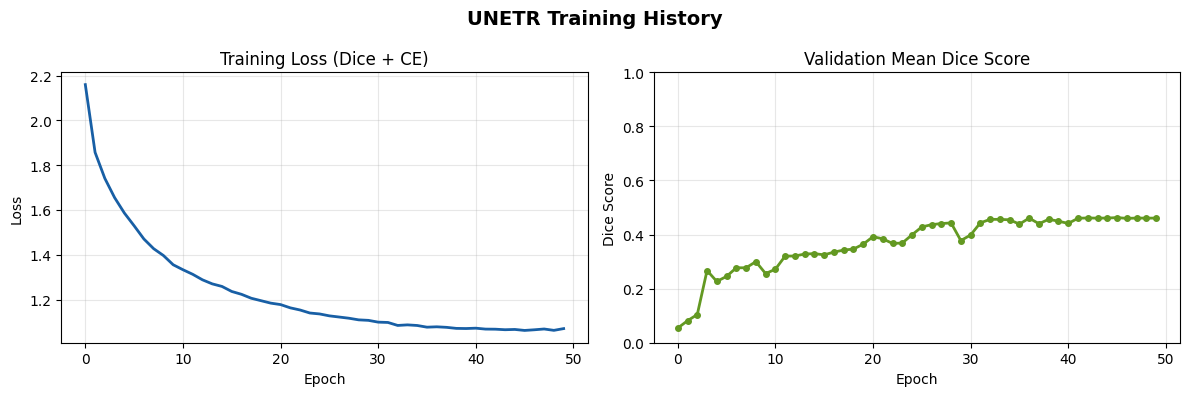


[3/3] Visualizing best model on a validation patient...

Visualizing Patient: BraTS-PED-00246-000 (Axial Slice 75)


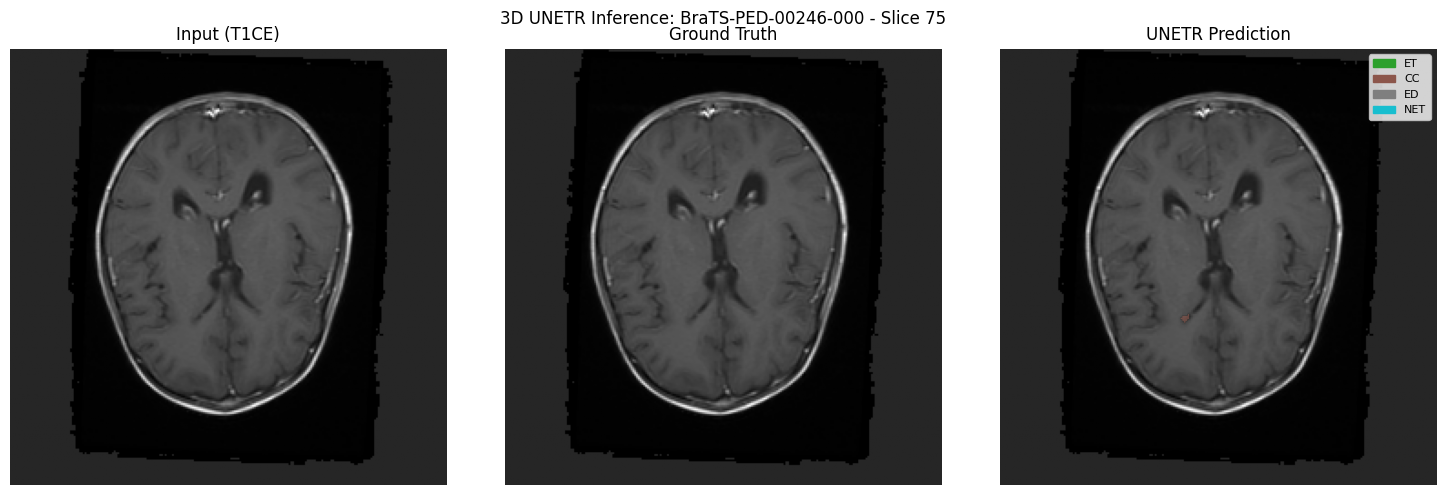


Pipeline execution complete. Results saved to /kaggle/working/results_unetr


In [1]:
"""
Final Project: Deep Vision Pipeline — 3D UNETR (30GB GPU / Low System RAM)
Dataset: BraTS-PEDs

Architecture: 3D UNETR (Vision Transformer)
Input:  3-channel 3D patches [T1CE, T2, FLAIR]  →  (B, 3, 96, 96, 96)
"""

import os
import glob
import random
import warnings
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import torch
from torch.cuda.amp import GradScaler, autocast

# MONAI
from monai.utils import set_determinism
from monai.networks.nets import UNETR  
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference
# ↓↓↓ CHANGED: Using standard Dataset instead of CacheDataset to save RAM
from monai.data import DataLoader, Dataset, decollate_batch
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, NormalizeIntensityd,
    RandCropByPosNegLabeld, RandFlipd, RandRotate90d, ConcatItemsd, DeleteItemsd,
    AsDiscrete
)

warnings.filterwarnings("ignore")

# ─────────────────────────────────────────────────────────────
# CONFIG 
# ─────────────────────────────────────────────────────────────
class Config:
    TRAIN_ROOT  = "/kaggle/input/datasets/muhammadmunsoorulhaq/cv-project/PKG - BraTS-PEDs-v1/BraTS-PEDs-v1/Training"
    CKPT_DIR    = "/kaggle/working/checkpoints_unetr"
    RESULTS     = "/kaggle/working/results_unetr"

    PATCH_SIZE  = (96, 96, 96)  # High GPU VRAM is fine, keep this large
    NUM_WORKERS = 4             # Multi-threading to speed up hard-drive reads
    BATCH_SIZE  = 2             
    ACCUM_STEPS = 4             
    
    NUM_EPOCHS  = 50
    LR          = 1e-4
    WEIGHT_DECAY= 1e-5
    NUM_CLASSES = 5

    LABEL_NAMES = {0: "BG", 1: "ET", 2: "CC", 3: "ED", 4: "NET"}
    BAD_CASES   = {"BraTS-PED-00024-000", "BraTS-PED-00098-000"}
    
    DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    SEED        = 42

cfg = Config()
os.makedirs(cfg.CKPT_DIR, exist_ok=True)
os.makedirs(cfg.RESULTS, exist_ok=True)
set_determinism(seed=cfg.SEED)


# ─────────────────────────────────────────────────────────────
# DATA PREPARATION 
# ─────────────────────────────────────────────────────────────
def get_patient_dicts(root: str) -> list[dict]:
    if not os.path.exists(root):
        print(f"CRITICAL ERROR: The path does not exist -> {root}")
        return []

    dirs = sorted(glob.glob(os.path.join(root, "BraTS-PED-*")))
    print(f"Scanning {root} ... Found {len(dirs)} patient folders.")
    
    pats = []
    
    def find_modality(patient_dir, keywords):
        for r_dir, _, files in os.walk(patient_dir):
            for file in files:
                if file.endswith((".nii", ".nii.gz")):
                    full_path_lower = os.path.join(r_dir, file).lower()
                    if any(kw in full_path_lower for kw in keywords):
                        return os.path.join(r_dir, file)
        return None

    for d in dirs:
        pid = os.path.basename(d)
        if pid in cfg.BAD_CASES: continue
        
        t1c = find_modality(d, ["t1c", "t1ce"])
        t2w = find_modality(d, ["t2w", "_t2_"])
        t2f = find_modality(d, ["t2f", "flair"])
        seg = find_modality(d, ["seg", "mask"])
        
        if t1c and t2w and t2f and seg:
            pats.append({"t1c": t1c, "t2w": t2w, "t2f": t2f, "label": seg, "id": pid})
        else:
            missing = []
            if not t1c: missing.append("T1CE")
            if not t2w: missing.append("T2")
            if not t2f: missing.append("FLAIR")
            if not seg: missing.append("SEGMENTATION")
            print(f"  [!] Skipping {pid} - Missing: {missing}")
            
    print(f"--> Successfully loaded {len(pats)} fully-labeled patients.")
    return pats


def get_transforms():
    keys = ["t1c", "t2w", "t2f", "label"]
    
    base = [
        LoadImaged(keys=keys),
        EnsureChannelFirstd(keys=keys),
        ConcatItemsd(keys=["t1c", "t2w", "t2f"], name="image"),
        DeleteItemsd(keys=["t1c", "t2w", "t2f"]), 
        NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True)
    ]
    
    train_transforms = Compose(base + [
        RandCropByPosNegLabeld(
            keys=["image", "label"], label_key="label", spatial_size=cfg.PATCH_SIZE,
            pos=1, neg=1, num_samples=2, image_key="image", image_threshold=0,
        ),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
        RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
        RandRotate90d(keys=["image", "label"], prob=0.5, max_k=3),
    ])
    
    return train_transforms, Compose(base)


# ─────────────────────────────────────────────────────────────
# MODEL
# ─────────────────────────────────────────────────────────────
def build_unetr():
    model = UNETR(
        in_channels=3,
        out_channels=cfg.NUM_CLASSES,
        img_size=cfg.PATCH_SIZE,
        feature_size=32,          
        hidden_size=768,          
        mlp_dim=3072,
        num_heads=12,
        res_block=True,
        dropout_rate=0.0
    ).to(cfg.DEVICE)
    return model


# ─────────────────────────────────────────────────────────────
# PLOTS & VISUALIZATION
# ─────────────────────────────────────────────────────────────
def plot_training_history(history: dict):
    if len(history["train_loss"]) == 0: return
        
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle("UNETR Training History", fontsize=14, fontweight="bold")

    ax1.plot(history["train_loss"], color="#185FA5", linewidth=2)
    ax1.set_title("Training Loss (Dice + CE)"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.grid(True, alpha=0.3)

    if len(history["val_dice"]) > 0:
        ax2.plot(history["val_dice"], color="#639922", linewidth=2, marker='o', markersize=4)
    ax2.set_title("Validation Mean Dice Score"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Dice Score")
    ax2.set_ylim(0, 1); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    out_path = os.path.join(cfg.RESULTS, "unetr_training_history.png")
    plt.savefig(out_path, dpi=150, bbox_inches="tight"); plt.show()


def visualize_3d_prediction(model, patient_dict, slice_idx=75):
    print(f"\nVisualizing Patient: {patient_dict['id']} (Axial Slice {slice_idx})")
    
    _, val_tf = get_transforms()
    val_ds = Dataset(data=[patient_dict], transform=val_tf)
    val_dl = DataLoader(val_ds, batch_size=1, num_workers=0)
    
    post_pred = AsDiscrete(argmax=True, to_onehot=cfg.NUM_CLASSES)
    model.eval()
    
    with torch.no_grad():
        for batch in val_dl:
            inputs = batch["image"].to(cfg.DEVICE)
            gt_label = batch["label"][0, 0].cpu().numpy()
            
            with autocast():
                outputs = sliding_window_inference(
                    inputs, cfg.PATCH_SIZE, 4, model, overlap=0.5
                )
            
            pred_vol = post_pred(outputs[0]).cpu().numpy()
            pred_class_map = np.argmax(pred_vol, axis=0)

            t1c_slice = inputs[0, 0].cpu().numpy()[:, :, slice_idx]
            gt_slice = gt_label[:, :, slice_idx]
            pred_slice = pred_class_map[:, :, slice_idx]

            fig, axes = plt.subplots(1, 3, figsize=(15, 5))
            fig.suptitle(f"3D UNETR Inference: {patient_dict['id']} - Slice {slice_idx}", fontsize=12)
            cmap = plt.cm.get_cmap("tab10", cfg.NUM_CLASSES)
            
            axes[0].imshow(t1c_slice.T, cmap="gray", origin="lower"); axes[0].set_title("Input (T1CE)"); axes[0].axis("off")
            axes[1].imshow(t1c_slice.T, cmap="gray", origin="lower")
            axes[1].imshow(np.ma.masked_where(gt_slice == 0, gt_slice).T, cmap=cmap, alpha=0.6, origin="lower", vmin=0, vmax=4)
            axes[1].set_title("Ground Truth"); axes[1].axis("off")
            axes[2].imshow(t1c_slice.T, cmap="gray", origin="lower")
            axes[2].imshow(np.ma.masked_where(pred_slice == 0, pred_slice).T, cmap=cmap, alpha=0.6, origin="lower", vmin=0, vmax=4)
            axes[2].set_title("UNETR Prediction"); axes[2].axis("off")
            
            patches = [mpatches.Patch(color=cmap(i), label=cfg.LABEL_NAMES[i]) for i in range(1, 5)]
            axes[2].legend(handles=patches, loc="upper right", fontsize=8)

            plt.tight_layout()
            out_path = os.path.join(cfg.RESULTS, f"unetr_pred_{patient_dict['id']}_sl{slice_idx}.png")
            plt.savefig(out_path, dpi=150); plt.show()
            break


# ─────────────────────────────────────────────────────────────
# TRAINING LOOP
# ─────────────────────────────────────────────────────────────
def train(train_pats, val_pats):
    train_tf, val_tf = get_transforms()

    print("\n[RAM SAVER] Initializing lazy-loading Datasets (reads from disk on the fly)...")
    # ↓↓↓ CHANGED: Removed CacheDataset ↓↓↓
    train_ds = Dataset(data=train_pats, transform=train_tf)
    val_ds   = Dataset(data=val_pats, transform=val_tf)

    train_dl = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE, shuffle=True, 
                          num_workers=cfg.NUM_WORKERS, pin_memory=True)
    val_dl   = DataLoader(val_ds, batch_size=1, shuffle=False, 
                          num_workers=cfg.NUM_WORKERS, pin_memory=True)

    model     = build_unetr()
    loss_fn   = DiceCELoss(to_onehot_y=True, softmax=True, include_background=False)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.NUM_EPOCHS)
    scaler    = GradScaler()

    dice_metric = DiceMetric(include_background=False, reduction="mean")
    post_pred   = AsDiscrete(argmax=True, to_onehot=cfg.NUM_CLASSES)
    post_label  = AsDiscrete(to_onehot=cfg.NUM_CLASSES)

    best_metric = -1
    history = {"train_loss": [], "val_dice": []}

    for epoch in range(cfg.NUM_EPOCHS):
        model.train()
        epoch_loss = 0
        optimizer.zero_grad()

        for step, batch_data in enumerate(train_dl):
            inputs, labels = batch_data["image"].to(cfg.DEVICE), batch_data["label"].to(cfg.DEVICE)

            with autocast():
                outputs = model(inputs)
                loss = loss_fn(outputs, labels) / cfg.ACCUM_STEPS

            scaler.scale(loss).backward()

            if (step + 1) % cfg.ACCUM_STEPS == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            epoch_loss += loss.item() * cfg.ACCUM_STEPS

        epoch_loss /= max(1, len(train_dl))
        history["train_loss"].append(epoch_loss)

        # ── VALIDATION ──
        if len(val_dl) == 0:
            print(f"Ep {epoch+1:03d}/{cfg.NUM_EPOCHS} | Loss: {epoch_loss:.4f} | Validation skipped")
            scheduler.step()
            continue

        model.eval()
        with torch.no_grad():
            for val_data in val_dl:
                val_inputs, val_labels = val_data["image"].to(cfg.DEVICE), val_data["label"].to(cfg.DEVICE)
                
                with autocast():
                    val_outputs = sliding_window_inference(
                        inputs=val_inputs, 
                        roi_size=cfg.PATCH_SIZE, 
                        sw_batch_size=4,
                        predictor=model,
                        overlap=0.5
                    )
                
                val_outputs = [post_pred(i) for i in decollate_batch(val_outputs)]
                val_labels  = [post_label(i) for i in decollate_batch(val_labels)]
                dice_metric(y_pred=val_outputs, y=val_labels)

            metric_mean = dice_metric.aggregate().item()
            dice_metric.reset()
            history["val_dice"].append(metric_mean)

            print(f"Ep {epoch+1:03d}/{cfg.NUM_EPOCHS} | Loss: {epoch_loss:.4f} | Val Mean Dice: {metric_mean:.4f}")

            if metric_mean > best_metric:
                best_metric = metric_mean
                torch.save(model.state_dict(), os.path.join(cfg.CKPT_DIR, "best_unetr.pt"))

        scheduler.step()

    return model, history


# ─────────────────────────────────────────────────────────────
# MAIN EXECUTION
# ─────────────────────────────────────────────────────────────
if __name__ == "__main__":
    all_labeled_patients = get_patient_dicts(cfg.TRAIN_ROOT)

    if len(all_labeled_patients) == 0:
        print("\nCRITICAL: No labeled patients found. Check your TRAIN_ROOT path.")
    else:
        rng = random.Random(cfg.SEED)
        rng.shuffle(all_labeled_patients)
        
        split_idx = int(len(all_labeled_patients) * 0.8)
        train_patients = all_labeled_patients[:split_idx]
        val_patients   = all_labeled_patients[split_idx:]
        
        print(f"\n[DATA SPLIT] Automatically splitting labeled data:")
        print(f"  --> {len(train_patients)} patients for Training")
        print(f"  --> {len(val_patients)} patients for Validation")

        print("\n[1/3] Training 3D UNETR...")
        model, history = train(train_patients, val_patients)
        
        print("\n[2/3] Plotting Training History...")
        plot_training_history(history)
        
        print("\n[3/3] Visualizing best model on a validation patient...")
        best_weights = os.path.join(cfg.CKPT_DIR, "best_unetr.pt")
        if os.path.exists(best_weights):
            model.load_state_dict(torch.load(best_weights, map_location=cfg.DEVICE))
        
        if len(val_patients) > 0:
            visualize_3d_prediction(model, val_patients[0], slice_idx=75)
            
        print(f"\nPipeline execution complete. Results saved to {cfg.RESULTS}")

In [2]:
pip install monai


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 29.0 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
import shutil
from IPython.display import FileLink

# Name of the output zip file (without the .zip extension)
output_filename = "my_trained_model_data"

# Directory you want to zip
directory_to_zip = "/kaggle/working/"

print("Zipping files... This might take a minute depending on the size.")

# Create the zip file
shutil.make_archive(output_filename, 'zip', directory_to_zip)

print("Done! Click the link below to download your files:")

# Generate the download link
FileLink(f"{output_filename}.zip")

Zipping files... This might take a minute depending on the size.
Done! Click the link below to download your files:


/kaggle/working/my_trained_model_data.zip